<a href="https://colab.research.google.com/github/barbararolska/Wizualizacja-danych/blob/main/Laboratorium_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wprowadzenie do Geopandas – Radykalna Kartografia
---

Witaj na kolejnych zajęciach z wizualizacji danych! Rozpoczynamy dzisiaj nową przygodę – wkraczamy w świat danych przestrzennych (geolokalizacyjnych) za pomocą pakietu **Geopandas**.

**Nasza filozofia na dziś:**
Podczas dzisiejszych zajęć będziemy opierać się na książce **„Radical Cartography: How Changing Our Maps Can Change Our World”** (William Rankin). Autor rzuca wyzwanie tradycyjnej kartografii. Zauważa, że standardowe mapy (np. te dzielące świat na równe, pokolorowane klocki) wcale nie są obiektywne. Wprowadzają one *Pułapkę Jurysdykcyjną* (Jurisdictional Trap) – zmuszają nas do myślenia o świecie przez pryzmat sztucznych granic administracyjnych, ukrywając to, co najważniejsze: płynne przejścia i rzeczywiste skupiska ludzi.

**Podczas tych zajęć nauczymy się:**
1. Wczytywać pliki przestrzenne (GeoJSON) z GitHuba i łączyć je z danymi (Zadanie 1).
2. Robić „Makeovery” map – przechodzić od tradycyjnych, mylących kartogramów (choropleths) do map punktowych (bubble maps), które lepiej oddają rzeczywistość (Zadanie 2).
3. Manipulować warstwami i tłem, aby granice administracyjne przestały dominować nad danymi (Zadania dodatkowe).

## Zadanie 1: Import, czyszczenie i agregacja danych przestrzennych
----

Zanim zaczniemy rysować, musimy przygotować nasze płótno. Wczytamy mapę Polski (podział na województwa) z publicznego repozytorium w formacie **GeoJSON**. Następnie połączymy ten zbiór ze standardowymi danymi demograficznymi (populacja w tysiącach).

**Co musisz wiedzieć o funkcjach w tym zadaniu:**
* `gpd.read_file(link)` – najważniejsza funkcja pakietu `geopandas`. Działa jak `pd.read_csv()`, ale potrafi wczytać pliki z mapami i tworzy z nich obiekt `GeoDataFrame` (tabelę z kolumną `geometry`).
* `.merge(tabela_prawa, left_on='...', right_on='...')` – klasyczna metoda Pandas do łączenia tabel. Łączymy mapę z danymi statystycznymi.

**Instrukcja krok po kroku:**
1. Zaimportuj pakiety: `pandas as pd`, `geopandas as gpd`, `matplotlib.pyplot as plt`. Ustaw styl `plt.style.use('default')`.
2. Zdefiniuj zmienną `url_mapa = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/poland.geojson"`.
3. Wczytaj mapę za pomocą `gpd.read_file()` i przypisz do zmiennej `gdf_polska`.
4. W kodzie poniżej przygotowałem dla Ciebie słownik `dane_populacja`. Zawiera on nazwy województw (zapisane z małej litery, by pasowały do formatu GeoJSON) oraz ich populację. Zamień ten słownik na obiekt `DataFrame` i przypisz do `df_dane`.
5. Wykonaj połączenie (`merge`). Lewą tabelą niech będzie `gdf_polska`, prawą `df_dane`. Klucz łączenia po lewej stronie to `'name'`, po prawej `'wojewodztwo'`. Wynik zapisz do `gdf_merged`.
6. Wyświetl nagłówek nowej tabeli (`.head()`), aby upewnić się, że obok kolumny `geometry` pojawiła się kolumna `populacja`.

In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
plt.style.use('default')
url_mapa = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/poland.geojson"
gdf_polska = gpd.read_file(url_mapa)

dane_populacja = {
    'wojewodztwo': ['mazowieckie', 'śląskie', 'wielkopolskie', 'małopolskie',
                    'dolnośląskie', 'łódzkie', 'pomorskie', 'podkarpackie',
                    'lubelskie', 'kujawsko-pomorskie', 'zachodniopomorskie',
                    'warmińsko-mazurskie', 'świętokrzyskie', 'podlaskie',
                    'lubuskie', 'opolskie'],
    'populacja': [5511, 4346, 3493, 3429, 2888, 2378, 2358, 2085, 2024, 2006, 1638, 1366, 1178, 1143, 984, 942]
}
gdf_polska['name'] = gdf_polska['name'].str.lower()
df_dane = pd.DataFrame(dane_populacja)
gdf_merged = gdf_polska.merge(df_dane, left_on='name', right_on='wojewodztwo')
gdf_merged.head()

,name,cartodb_id,created_at,updated_at,geometry,wojewodztwo,populacja
0,świętokrzyskie,2,2013-11-28 06:27:08+01:00,2013-11-28 06:28:13+01:00,"MULTIPOLYGON (((20.70706 51.14639, 20.7106 51....",świętokrzyskie,1178
1,wielkopolskie,3,2013-11-28 06:27:08+01:00,2013-11-28 06:27:08+01:00,"MULTIPOLYGON (((16.92182 53.59652, 16.94772 53...",wielkopolskie,3493
2,kujawsko-pomorskie,4,2013-11-28 06:27:08+01:00,2013-11-28 06:27:08+01:00,"MULTIPOLYGON (((18.25566 53.69423, 18.27436 53...",kujawsko-pomorskie,2006
3,lubelskie,7,2013-11-28 06:27:08+01:00,2013-11-28 06:27:08+01:00,"MULTIPOLYGON (((23.1999 52.29715, 23.19235 52....",lubelskie,2024
4,małopolskie,5,2013-11-28 06:27:08+01:00,2013-11-28 06:28:59+01:00,"MULTIPOLYGON (((20.15906 50.43463, 20.17672 50...",małopolskie,3429


## Zadanie 2: Makeover cz. 1 – Ucieczka z "Pułapki Jurysdykcyjnej"
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 1 "Boundaries", podrozdział "The Jurisdictional Trap", s. 55-61).*

W swojej książce Rankin mocno krytykuje standardowe kartogramy (mapy, gdzie całe terytoria wypełnione są jednym kolorem). Nazywa to **„jigsaw-puzzle maps”** (mapy jak z puzzli).
Dlaczego są złe? Ponieważ sprawiają, że wielkie, słabo zaludnione obszary dominują na wykresie, a małe, gęsto zaludnione znikają (np. terytorium Mazowsza całkowicie dominuje nad Śląskiem, mimo że różnica w populacji wcale nie jest tak drastyczna). Tworzy to iluzję, że zjawiska społeczne (np. populacja) są jednorodne na całym zamalowanym obszarze.

Zrobimy Makeover! Zamiast tradycyjnego kartogramu, stworzymy **Bubble Map** (Mapę bąbelkową). Ludzie nie zajmują całego terytorium województwa w równym stopniu – żyją w skupiskach.

**Nowe funkcje:**
* `gdf.centroid` – wylicza geometryczny środek ciężkości każdego wielokąta (województwa).
* `ax.scatter(x, y, s=rozmiar)` – pozwala narysować kropki w podanych koordynatach X i Y.
* `ax.text(...)` – użyjemy do podpisania kropek odpowiednimi wartościami.
* `ax.axis('off')` – wyłącza niepotrzebne osie współrzędnych geograficznych.

**Instrukcja krok po kroku:**
1. Oblicz środki ciężkości województw: stwórz kolumnę `gdf_merged['srodek'] = gdf_merged.geometry.centroid`.
2. Wyciągnij koordynaty X (długość) i Y (szerokość) z wyliczonego środka:
   * `x = gdf_merged['srodek'].x`
   * `y = gdf_merged['srodek'].y`
3. Stwórz zestaw dwóch wykresów obok siebie: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))`.
4. **Wykres 1 (ZŁY - Kartogram):**
   * Użyj: `gdf_merged.plot(column='populacja', cmap='Reds', ax=ax1, edgecolor='black', legend=True)`. Parametr `legend=True` wygeneruje nam z boku tzw. colorbar (pasek skali barwnej).
   * Nadaj tytuł: *"BEFORE: Jigsaw-puzzle map (Pułapka Jurysdykcyjna)\nWielkie terytoria dominują wizualnie nad rzeczywistym zaludnieniem."*.
5. **Wykres 2 (DOBRY - Bubble Map):**
   * Najpierw narysuj same kontury województw jako delikatne tło: `gdf_merged.plot(ax=ax2, color='whitesmoke', edgecolor='silver')`.
   * Następnie nanieś "bąble" reprezentujące populację: `ax2.scatter(x, y, s=gdf_merged['populacja']/3, color='crimson', alpha=0.7)`. (Dzielimy populację przez 3 dla lepszego skalowania wewnątrz Matplotlib).
   * Nałóż etykiety: stwórz pętlę po wierszach (`for i, row in gdf_merged.iterrows():`) i dodaj podpisy tuż pod kropkami uzywając `ax2.text(...)`. Sformatuj podpis tak, aby wyświetlał liczbę ludności i dopisek "tys." (np. "4346 tys."). Koordynaty tekstu to `row['srodek'].x` oraz `row['srodek'].y - 0.2`.
   * Nadaj tytuł: *"AFTER: Ludzie to nie terytorium (Bubble Map)\nUwaga widza skupia się na masie (populacji), a nie na metrach kwadratowych."*.
6. Na obu osiach (`ax1` i `ax2`) wyłącz ramki i współrzędne za pomocą `.axis('off')`. Użyj `plt.tight_layout()` i wyświetl wykres.

/tmp/ipykernel_3391/288897074.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_merged['srodek'] = gdf_merged.geometry.centroid


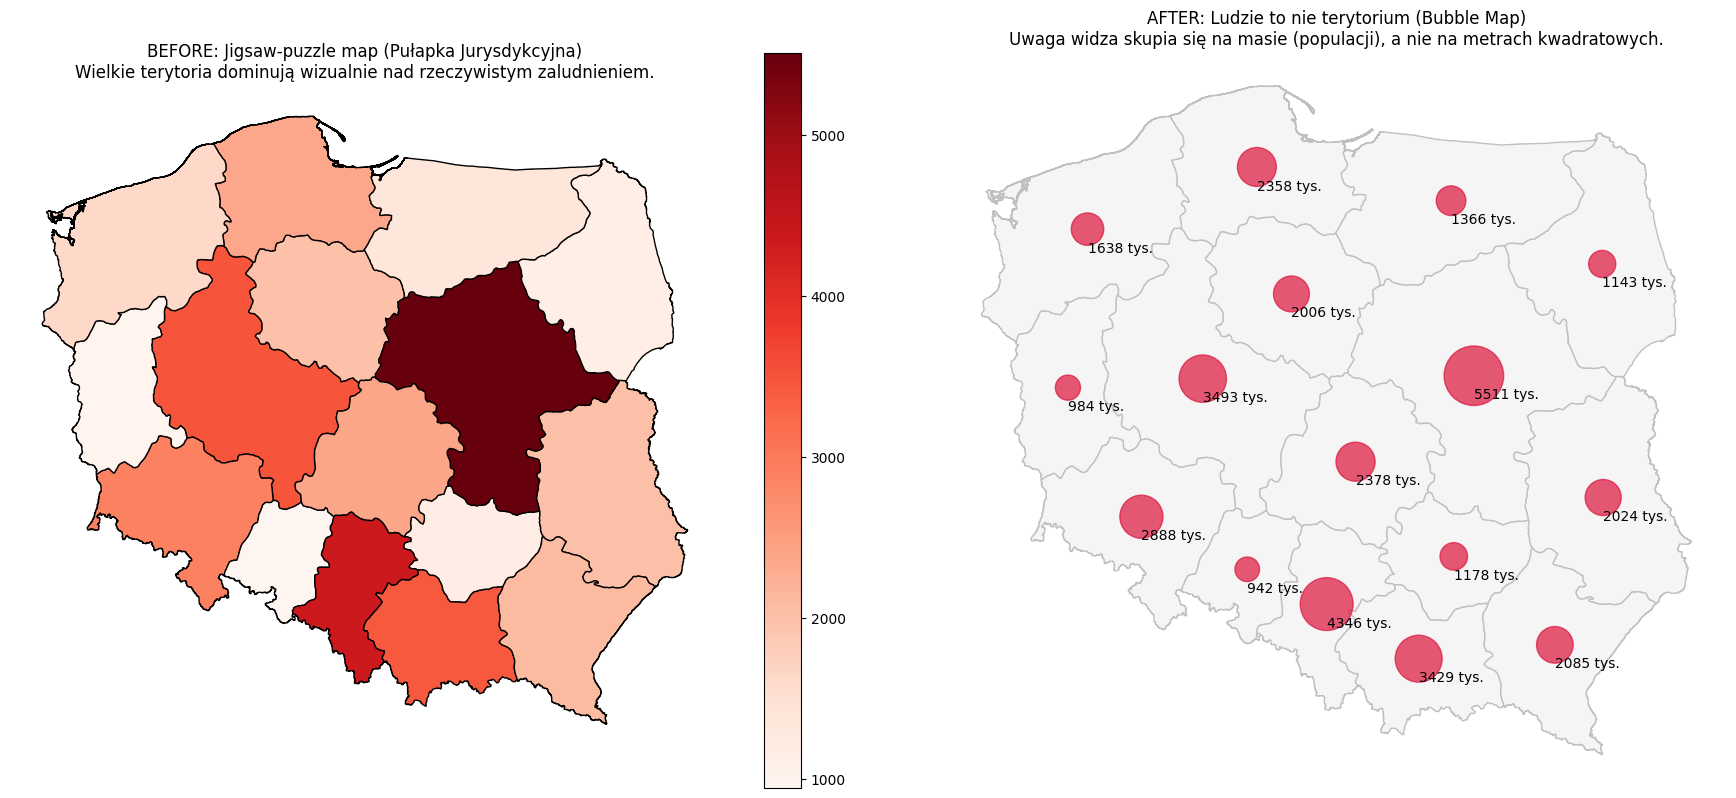

In [8]:
# @title Miejsce na Twój kod
gdf_merged['srodek'] = gdf_merged.geometry.centroid
x = gdf_merged['srodek'].x
y = gdf_merged['srodek'].y
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
gdf_merged.plot(column='populacja', cmap='Reds', ax=ax1, edgecolor='black', legend=True)
ax1.set_title("BEFORE: Jigsaw-puzzle map (Pułapka Jurysdykcyjna)\nWielkie terytoria dominują wizualnie nad rzeczywistym zaludnieniem.")
gdf_merged.plot(ax=ax2, color='whitesmoke', edgecolor='silver')
ax2.scatter(x, y, s=gdf_merged['populacja']/3, color='crimson', alpha=0.7)
for i, row in gdf_merged.iterrows():
    ax2.text(row['srodek'].x, row['srodek'].y - 0.2, f"{row['populacja']} tys.", fontsize=10)
ax2.set_title("AFTER: Ludzie to nie terytorium (Bubble Map)\nUwaga widza skupia się na masie (populacji), a nie na metrach kwadratowych.")
ax1.axis('off')
ax2.axis('off')
plt.tight_layout()
plt.show()

## Zadanie 3: Makeover cz. 2 – Zniszczenie hierarchii warstw
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 2 "Layers", podrozdział "Layers in the Service of the State", s. 79-88).*

W poprzednim zadaniu zrobiliśmy krok w dobrą stronę, wprowadzając mapę bąbelkową. Jednak Rankin zwraca uwagę na kolejny problem: hierarchię warstw. W tradycyjnej kartografii zawsze mamy "twardą" bazę (obrysy państw, terytoriów) i "płynne" dane nanoszone na nią (kropki, wykresy). To podświadomie narzuca nam myślenie o zjawiskach ludzkich jako o czymś wtórnym wobec granic administracyjnych.

Co by było, gdybyśmy całkowicie usunęli "bezpieczną bazę" w postaci granic państwa? Sprawdźmy to!

**Instrukcja krok po kroku:**
1. Skopiuj szkielet kodu z poprzedniego zadania: stwórz dwa wykresy obok siebie `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))`.
2. **Wykres 1 (BEFORE):** Narysuj na nim „dobrą” mapę z Zadania 2 (czyli szare tło Polski + czerwone bąble populacji, wraz z podpisami liczb pod kropkami). **Nie dodawaj** paska kolorów (colorbar). Nadaj wykresowi tytuł przypominający, że ludzie wciąż są tu zaledwie "nakładką" na wytyczone terytorium państwa.
3. **Wykres 2 (AFTER):**
   * **Zignoruj** rysowanie tła mapy (`gdf_merged.plot(color='whitesmoke')`).
   * Narysuj TYLKO kropki na czystym tle (`ax2.scatter(x, y, s=gdf_merged['populacja']/3, color='indigo', alpha=0.6)`).
   * Aby mapa była czytelna, użyj pętli `for i, row in gdf_merged.iterrows():` do wygenerowania wieloliniowych etykiet.
   * Sformatuj etykietę tak, aby zawierała nazwę województwa w jednej linijce, a pod nią (za pomocą znaku łamania wiersza `\n`) liczbę ludności, np.: `f"{row['wojewodztwo'].capitalize()}\n{row['populacja']} tys."`.
   * Zobacz różnicę względem wykresu po lewej – tutaj same słowa i liczby muszą nakreślić terytorium kraju. Umieść etykiety nieco poniżej samych kropek (`row['srodek'].y - 0.25`).
4. Wyłącz osie na obu wykresach i wyświetl wynik używając `plt.tight_layout()`.

**Lekcja Storytellingu:** Zobacz, jak na wykresie po prawej stronie same dane (ludzie i wartości liczbowe) potrafią zarysować kształt kraju, bez pomocy sztucznych, politycznych linii. Prowokuje to widza do myślenia o państwie jako o sieci powiązanych ze sobą społeczności, a nie tylko o wytyczonym na ziemi pustym obszarze.

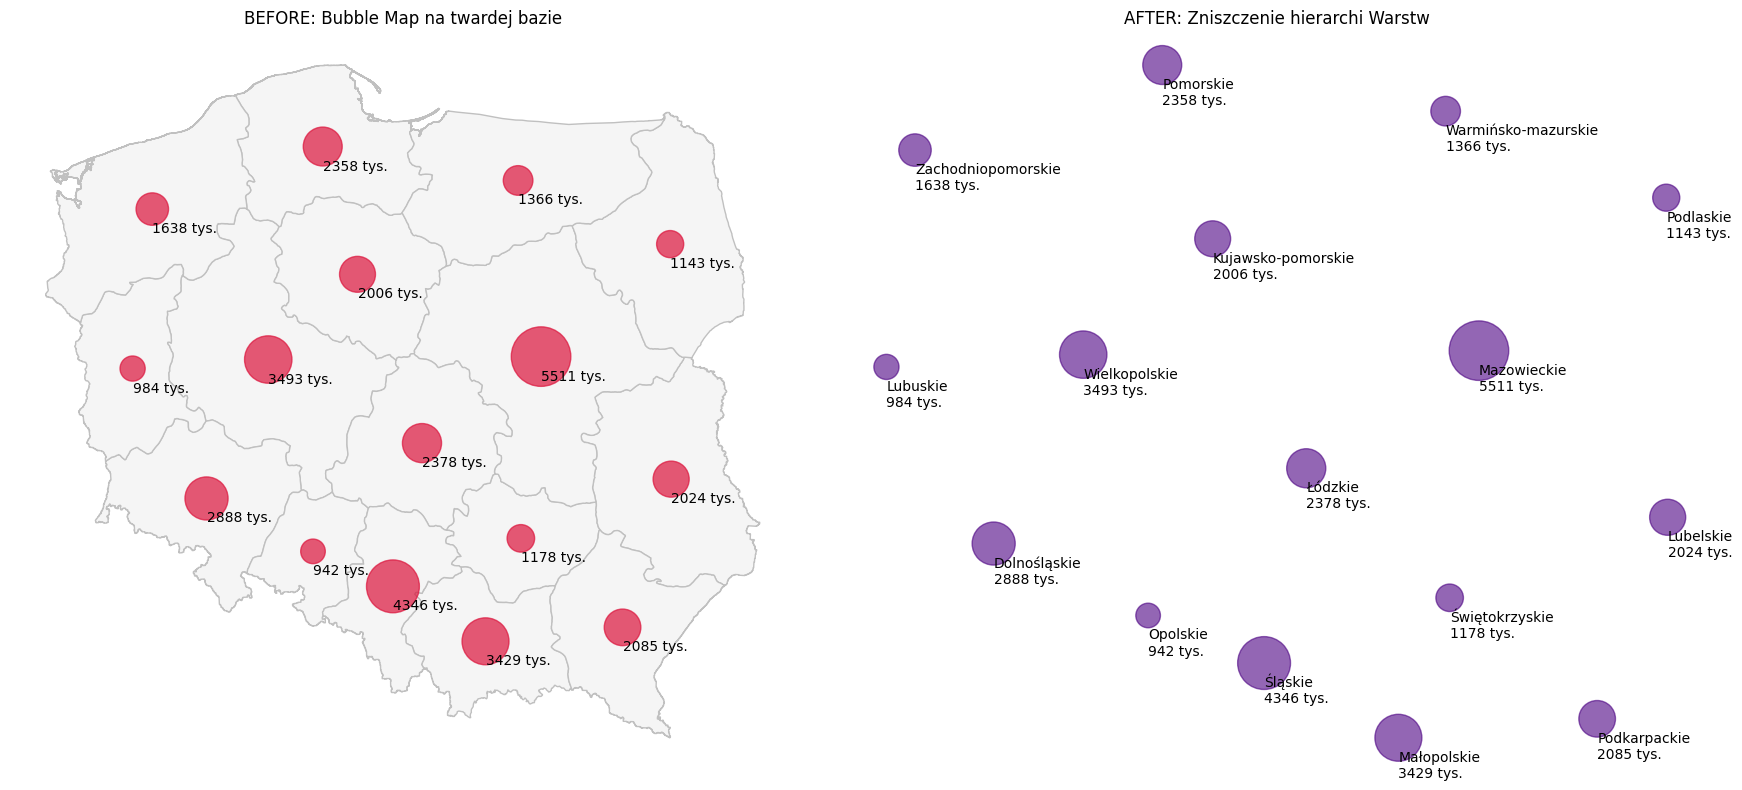

In [11]:
#@title Miejsce na Twój kod
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
gdf_merged.plot(ax=ax1, color='whitesmoke', edgecolor='silver')
ax1.scatter(x, y, s=gdf_merged['populacja']/3, color='crimson', alpha=0.7)
for i, row in gdf_merged.iterrows():
    ax1.text(row['srodek'].x, row['srodek'].y - 0.2, f"{row['populacja']} tys.", fontsize=10)
ax1.set_title("BEFORE: Bubble Map na twardej bazie")
ax1.axis('off')
#gdf_merged.plot(color='whitesmoke')
ax2.scatter(x, y, s=gdf_merged['populacja']/3, color='indigo', alpha=0.6)
for i, row in gdf_merged.iterrows():
    ax2.text(row['srodek'].x, row['srodek'].y - 0.25, f"{row['wojewodztwo'].capitalize()}\n{row['populacja']} tys.", fontsize = 10)
ax2.axis('off')
ax2.set_title("AFTER: Zniszczenie hierarchi Warstw")
plt.tight_layout()
plt.show()

## Zadania dodatkowe dla chętnych
---

W tej sekcji pogłębimy radykalne podejście do kartografii, testując, jak bardzo matematyka kolorów i wybór mianownika wpływają na to, w co uwierzy widz.

### Zadanie Dodatkowe A: Świat nie jest liniowy (Krytyka palet kolorów)
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 5 "Color", podrozdział "The World Is Not Linear", s. 206-214).*

Rankin krytykuje liniowe skale kolorów (np. te od białego, przez różowy, do czarnego), które domyślnie serwuje nam oprogramowanie. Twierdzi, że świat rzadko rozkłada się równomiernie. Najwyższe wartości (np. góry, czy zagęszczenie w metropoliach) rosną eksponencjalnie. Kiedy używamy liniowej palety kolorów, sztucznie **spłaszczamy nierówności na świecie**.
Stwórz mapę punktową (`ax.scatter()`), gdzie wielkość kropki wynosi zawsze 100, ale jej kolor reprezentuje populację (`c=gdf_merged['populacja']`). Wygeneruj wykres dwukrotnie:
* Raz używając liniowej skali kolorów (`cmap='Reds'`).
* Drugi raz sztucznie eksponując ekstremalne wartości za pomocą mapowania nieliniowego. Możesz to zrobić manipulując parametrem `vmax` (obniżając go, by szybciej osiągnąć głęboką czerwień) lub stosując własną, nieliniową transformację kolorów.
Zauważ, jak „łagodna” wydaje się pierwsza mapa w porównaniu do brutalnie wyraźnego podziału na drugiej.

### Zadanie Dodatkowe B: Wizualny mianownik – zmiana jednostki odniesienia
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 3 "People", podrozdział "The World Is Not Data", s. 134-136).*

Wracamy do „Wizualnego Mianownika” (Visual Denominator). Kartogram uczy nas odnosić dane do wielkości terenu. A co, gdy znormalizujemy dane?
Oblicz gęstość zaludnienia (Populacja / Pole powierzchni). W Geopandas wielkość wielokąta można łatwo wyciągnąć poleceniem `gdf.geometry.area`.
**Instrukcja:**
Wylicz nową kolumnę: `gdf_merged['gestosc'] = gdf_merged['populacja'] / gdf_merged.geometry.area`.
Następnie narysuj klasyczny kartogram, używając `column='gestosc'` oraz nowej palety barw (np. `cmap='Purples'`). Zwróć uwagę, jak zmiana z wartości absolutnej na gęstość kompletnie zmienia środek ciężkości kraju z gigantycznego Mazowsza na Śląsk i Małopolskę.

*(Napisz kod dla Zadania A i B w jednej figurze z dwoma subplotami `(1, 2)` w poniższej komórce).*

/tmp/ipykernel_3391/3736441506.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_merged['gestosc'] = gdf_merged['populacja'] / gdf_merged.geometry.area


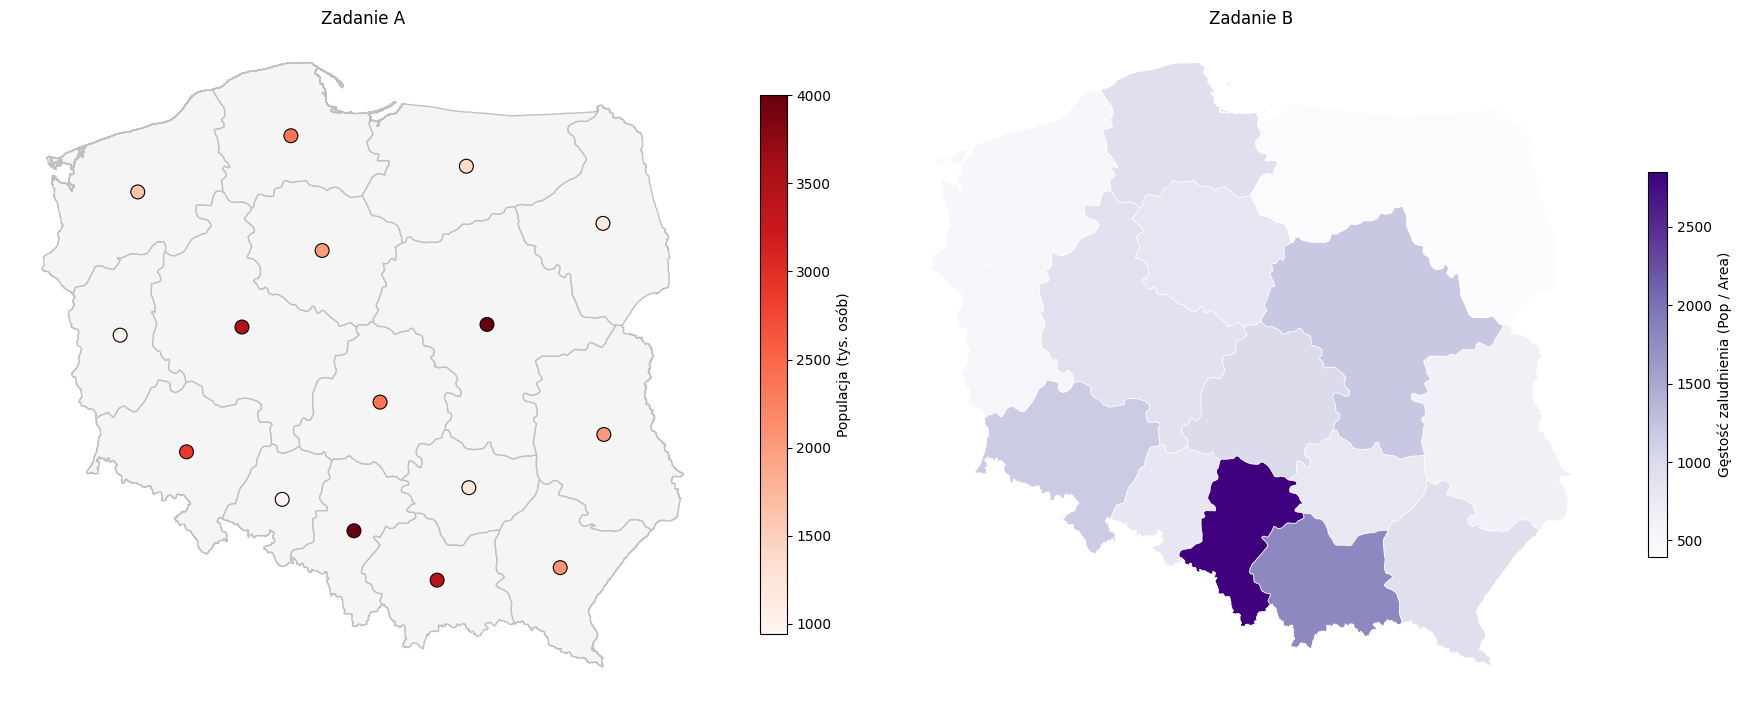

In [29]:
# @title Miejsce na Twój kod
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
gdf_merged.plot(ax=ax1, color='whitesmoke', edgecolor='silver')
sc = ax1.scatter(x, y, s=100, c=gdf_merged['populacja'], alpha=1, cmap = 'Reds', vmax = 4000, edgecolors='black', linewidths=0.8)
plt.colorbar(sc, ax=ax1, label='Populacja (tys. osób)', shrink=0.7)
ax1.set_title("Zadanie A")
ax1.axis('off')
gdf_merged['gestosc'] = gdf_merged['populacja'] / gdf_merged.geometry.area
gdf_merged.plot(column='gestosc', ax=ax2, cmap='Purples',
                legend=True, edgecolor='white', linewidth=0.5,
                legend_kwds={'label': "Gęstość zaludnienia (Pop / Area)", 'shrink': 0.5})
ax2.axis('off')
ax2.set_title("Zadanie B")
plt.tight_layout()
plt.show()